# Late Fusion Model with EEG Modality

This notebook implements late fusion combining **four modalities**:
- **Physiological data** (pupil metrics)
- **Behavioral data** (reaction time, decision time, etc.)
- **Gaze data** (gaze position, movements, fixations)
- **EEG data** (band power features across brain regions)

**Note**: 
- EEG data is available for **85 subjects** (82 overlap with extracted features)
- This notebook should be run with `TIMEFRAME = 'PRE'`

Goals:
1. Load and merge EEG features with other modalities
2. Train separate models for each modality
3. Implement late fusion (average, weighted, stacking)
4. Extract weights to estimate modality influence on predictions
5. Compare performance with and without EEG

In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================
TIMEFRAME = 'PRE'  # Fixed to PRE for merging with extracted_features_PRE

# EEG feature strategy - choose which level of features to use:
#   'channels_raw'   - 20 features: total power per electrode (base)
#   'regional_raw'   - 4 features: regional averages of total power
#   'channels_bands' - 80 features: 20 channels × 4 frequency bands
#   'regional_bands' - 16 features: 4 regions × 4 frequency bands (default)
#   'extended'       - 160 features: channels_bands + lateralization + temporal
EEG_STRATEGY = 'regional_bands'
# ============================================================================

import sys
sys.path.append('../..')  # Add project root to path

import json
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import from src package
from src.utils.io import load_features, save_results
from src.utils.config import get_model_params, load_config
from src.utils.validation import validate_features, validate_modality_features
from src.models.fusion import weighted_late_fusion
from src.visualization.plots import (
    plot_method_comparison,
    plot_modality_weights,
    set_style
)

np.random.seed(42)
set_style('whitegrid')  # Use shared style function

print(f"\n{'='*70}")
print(f"LATE FUSION WITH EEG: {TIMEFRAME}-DECISION PERIOD")
print(f"EEG Strategy: {EEG_STRATEGY}")
print(f"{'='*70}\n")


LATE FUSION WITH EEG: PRE-DECISION PERIOD
EEG Strategy: regional_bands



## 1. Load Pre-Extracted Features (All Modalities)

In [2]:
# Load configuration
config = load_config('model_params')
time_window = config['time_windows'][f'{TIMEFRAME.lower()}_decision']

print(f"Time window: {time_window['start']}s to {time_window['end']}s")
print(f"Description: {time_window['description']}\n")

# Load pre-extracted features (physio, behavior, gaze)
features_path = f'../../data/features/extracted_features_{TIMEFRAME}.pkl'
feature_data = load_features(features_path, timeframe=TIMEFRAME)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

print(f"Loaded {len(merged_df)} trials from {merged_df['subject_id'].nunique()} subjects")
print(f"\nFeature counts:")
print(f"  Physiology ({TIMEFRAME}): {len(physio_cols)} features")
print(f"  Behavior: {len(behavior_cols)} features")
print(f"  Gaze: {len(gaze_cols)} features")

Time window: -2.0s to 0.0s
Description: Anticipatory period before submit button

Loaded 12107 trials from 102 subjects

Feature counts:
  Physiology (PRE): 13 features
  Behavior: 11 features
  Gaze: 20 features


## 2. Load Pre-Extracted EEG Features

In [3]:
# Load pre-extracted EEG features based on selected strategy
# These pkl files are generated by 01_eeg_feature_extraction.ipynb

eeg_feature_file = f'../../data/features/eeg_features_{EEG_STRATEGY}.pkl'
print(f"Loading pre-extracted EEG features from: {eeg_feature_file}")

with open(eeg_feature_file, 'rb') as f:
    eeg_data = pickle.load(f)

eeg_features_df = eeg_data['eeg_features_df']
eeg_cols = eeg_data['feature_columns']

print(f"Loaded {len(eeg_features_df)} EEG trials from {eeg_features_df['subject_id'].nunique()} subjects")
print(f"EEG features ({len(eeg_cols)}): {eeg_cols[:5]}..." if len(eeg_cols) > 5 else f"EEG features ({len(eeg_cols)}): {eeg_cols}")
print(f"\nMetadata: {eeg_data['metadata']}")

Loading pre-extracted EEG features from: ../../data/features/eeg_features_regional_bands.pkl
Loaded 10212 EEG trials from 80 subjects
EEG features (16): ['eeg_Delta_Frontal', 'eeg_Delta_Central', 'eeg_Delta_Parietal', 'eeg_Delta_Occipital', 'eeg_Theta_Frontal']...

Metadata: {'strategy': 'regional_bands', 'level': 3, 'builds_on': 'channels_bands', 'sampling_rate': 256, 'frequency_bands': {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30)}, 'regions': ['Frontal', 'Central', 'Parietal', 'Occipital'], 'channels': ['Fp1', 'F7', 'F8', 'T4', 'T6', 'T5', 'T3', 'Fp2', 'O1', 'P3', 'Pz', 'F3', 'Fz', 'F4', 'C4', 'P4', 'POz', 'C3', 'Cz', 'O2'], 'n_channels': 20, 'n_regions': 4, 'n_features': 16, 'feature_types': ['regional_band_power'], 'extraction_date': '2026-04-17 10:00:58', 'n_trials': 10212, 'n_subjects': 80, 'input_file': PosixPath('/Users/pranmodu/Projects/columbia/liinc_eye/data/eeg/display_window_2s.pkl'), 'description': 'EEG features extracted using regional_bands st

## 3. Merge Features and Filter to EEG Subjects

In [4]:
# Get EEG subjects
eeg_subjects = eeg_features_df['subject_id'].unique()
print(f"EEG subjects ({len(eeg_subjects)}): {eeg_subjects}")

# Filter merged_df to only EEG subjects
merged_df_eeg = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()
print(f"\nFiltered to EEG subjects: {len(merged_df_eeg)} trials")

# Merge with EEG features on trial_id
merged_df_eeg = merged_df_eeg.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

print(f"After merging with EEG: {len(merged_df_eeg)} trials")
print(f"Subjects: {merged_df_eeg['subject_id'].nunique()}")
print(f"Trials per subject: {merged_df_eeg.groupby('subject_id').size().to_dict()}")

# Check outcome balance
outcome_counts = merged_df_eeg['outcome'].value_counts()
print(f"\nOutcome balance: {outcome_counts.get(0, 0)} keep / {outcome_counts.get(1, 0)} invest")

EEG subjects (80): <StringArray>
['0731_1000_U9TEJGM', '0802_1400_U9TEJGM', '0811_1000_4LI8GO7',
 '0811_1000_U9TEJGM', '0813_1000_9M4VCHG', '0813_1000_U9TEJGM',
 '0816_1400_539136F', '0816_1400_9M4VCHG', '0816_1400_U9TEJGM',
 '0817_1000_539136F', '0817_1000_9M4VCHG', '0817_1000_U9TEJGM',
 '0818_1600_539136F', '0818_1600_9M4VCHG', '0818_1600_U9TEJGM',
 '0819_1400_539136F', '0819_1400_9M4VCHG', '0823_1400_539136F',
 '0823_1400_9M4VCHG', '0823_1400_U9TEJGM', '0824_1000_539136F',
 '0824_1000_9M4VCHG', '0824_1000_U9TEJGM', '0824_1600_539136F',
 '0824_1600_9M4VCHG', '0826_1000_539136F', '0826_1000_9M4VCHG',
 '0826_1300_539136F', '0826_1300_9M4VCHG', '0826_1300_U9TEJGM',
 '0827_1000_539136F', '0827_1000_9M4VCHG', '0827_1000_U9TEJGM',
 '0828_1300_9M4VCHG', '0828_1300_U9TEJGM', '0830_1300_539136F',
 '0830_1300_9M4VCHG', '0830_1300_U9TEJGM', '0831_1300_539136F',
 '0831_1300_9M4VCHG', '0831_1300_U9TEJGM', '0901_1000_539136F',
 '0901_1000_9M4VCHG', '0901_1000_U9TEJGM', '0901_1300_539136F',
 '0901_

## 4. Prepare Feature Sets

In [5]:
# Prepare feature arrays for model training
X_physio = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[physio_cols])
X_behavior = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[behavior_cols])

# Handle gaze features (may be limited in POST)
if len(gaze_cols) > 0:
    X_gaze = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[gaze_cols])
else:
    # Create placeholder array (no gaze data)
    X_gaze = np.zeros((len(merged_df_eeg), 1))

# EEG features
X_eeg = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[eeg_cols])

y = merged_df_eeg['outcome'].values
subjects = merged_df_eeg['subject_id'].values

print(f"Shapes:")
print(f"  X_physio:   {X_physio.shape}")
print(f"  X_behavior: {X_behavior.shape}")
print(f"  X_gaze:     {X_gaze.shape}")
print(f"  X_eeg:      {X_eeg.shape}")
print(f"  y:          {y.shape}")

Shapes:
  X_physio:   (9365, 13)
  X_behavior: (9365, 11)
  X_gaze:     (9365, 20)
  X_eeg:      (9365, 16)
  y:          (9365,)


In [6]:
def train_evaluate_modality(X, y, subjects, modality_name):
    """
    Train and evaluate a single modality using LOSO cross-validation.
    
    Parameters
    ----------
    X : np.ndarray
        Feature matrix for the modality
    y : np.ndarray
        Target labels
    subjects : np.ndarray
        Subject IDs for each sample
    modality_name : str
        Name of the modality
    
    Returns
    -------
    tuple
        (model, accuracy, f1_score, predictions, y_true)
    """
    logo = LeaveOneGroupOut()
    
    # Get model parameters from config
    model_params = get_model_params('random_forest')
    
    # Initialize storage
    all_preds = []
    all_y_true = []
    subject_accs = []
    subject_f1s = []
    
    print(f"\n{'='*50}")
    print(f"{modality_name} Model")
    print(f"{'='*50}")
    
    # LOSO cross-validation
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train model
        model = RandomForestClassifier(**model_params)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Store results
        all_preds.extend(y_pred)
        all_y_true.extend(y_test)
        
        # Subject-level metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        subject_accs.append(acc)
        subject_f1s.append(f1)
    
    # Calculate overall metrics
    overall_acc = np.mean(subject_accs)
    overall_f1 = np.mean(subject_f1s)
    
    print(f"Accuracy: {overall_acc:.3f} +/- {stats.sem(subject_accs):.3f}")
    print(f"F1-Score: {overall_f1:.3f} +/- {stats.sem(subject_f1s):.3f}")
    print(f"N subjects: {len(subject_accs)}")
    
    return model, overall_acc, overall_f1, np.array(all_preds), np.array(all_y_true)

## 5. Train Individual Modality Models

In [7]:
model_physio, acc_physio, f1_physio, pred_physio, y_true = train_evaluate_modality(
    X_physio, y, subjects, "Physiology"
)
model_behavior, acc_behavior, f1_behavior, pred_behavior, _ = train_evaluate_modality(
    X_behavior, y, subjects, "Behavior"
)

# Only train gaze model if gaze data exists
if len(gaze_cols) > 0:
    model_gaze, acc_gaze, f1_gaze, pred_gaze, _ = train_evaluate_modality(
        X_gaze, y, subjects, "Gaze"
    )
else:
    # Placeholder for POST (no gaze data)
    model_gaze = None
    acc_gaze = 0.5
    f1_gaze = 0.5
    pred_gaze = np.zeros(len(y))
    print(f"\n{'='*50}\nGaze Model\n{'='*50}")
    print("Skipping - no gaze data available (POST condition)")

# Train EEG model
model_eeg, acc_eeg, f1_eeg, pred_eeg, _ = train_evaluate_modality(
    X_eeg, y, subjects, "EEG"
)


Physiology Model


/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

Accuracy: 0.514 +/- 0.016
F1-Score: 0.501 +/- 0.020
N subjects: 80

Behavior Model


/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

Accuracy: 0.711 +/- 0.015
F1-Score: 0.705 +/- 0.016
N subjects: 80

Gaze Model
Accuracy: 0.622 +/- 0.015
F1-Score: 0.625 +/- 0.017
N subjects: 80

EEG Model
Accuracy: 0.566 +/- 0.017
F1-Score: 0.547 +/- 0.020
N subjects: 80


## 6. Late Fusion Implementation

Using shared `weighted_late_fusion` function from `src.models.fusion` with 4 modalities.

In [8]:
# Run fusion methods with all 4 modalities
if len(gaze_cols) > 0:
    X_modalities = [X_physio, X_behavior, X_gaze, X_eeg]
    modality_names = ['Physiology', 'Behavior', 'Gaze', 'EEG']
else:
    # POST condition: no gaze data
    X_modalities = [X_physio, X_behavior, X_eeg]
    modality_names = ['Physiology', 'Behavior', 'EEG']

# Validate modalities before fusion
validate_modality_features(X_modalities, y, subjects, modality_names)

print("\nRunning fusion methods with EEG...")
results_avg = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                   fusion_method='average')
results_weighted = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                        fusion_method='weighted')
results_stacking = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                        fusion_method='stacking')

✓ Modality validation passed:
  Physiology: 9365 samples × 13 features
  Behavior: 9365 samples × 11 features
  Gaze: 9365 samples × 20 features
  EEG: 9365 samples × 16 features

Running fusion methods with EEG...


/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

## 7. Compare All Methods


PERFORMANCE COMPARISON (PRE) - WITH EEG (N=80 subjects)
         Method  Accuracy  F1-Score
Physiology Only  0.514322  0.500886
  Behavior Only  0.711140  0.705213
      Gaze Only  0.621730  0.625305
       EEG Only  0.565707  0.547251
 Average Fusion  0.703721  0.691886
Weighted Fusion  0.749262  0.737662
       Stacking  0.721177  0.714613


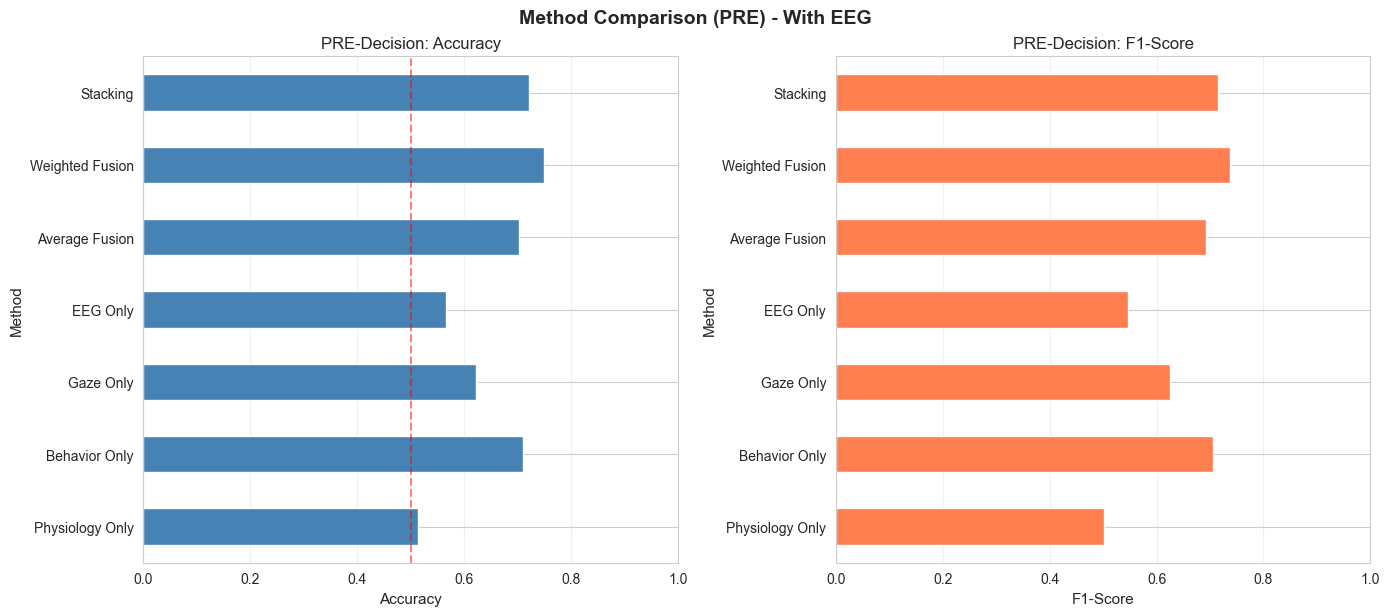

In [9]:
# Build comparison dataframe
comparison_data = {
    'Method': ['Physiology Only', 'Behavior Only'],
    'Accuracy': [acc_physio, acc_behavior],
    'F1-Score': [f1_physio, f1_behavior]
}

# Add gaze if available
if len(gaze_cols) > 0:
    comparison_data['Method'].append('Gaze Only')
    comparison_data['Accuracy'].append(acc_gaze)
    comparison_data['F1-Score'].append(f1_gaze)

# Add EEG
comparison_data['Method'].append('EEG Only')
comparison_data['Accuracy'].append(acc_eeg)
comparison_data['F1-Score'].append(f1_eeg)

# Add fusion methods
comparison_data['Method'].extend(['Average Fusion', 'Weighted Fusion', 'Stacking'])
comparison_data['Accuracy'].extend([
    results_avg['accuracy_mean'],
    results_weighted['accuracy_mean'],
    results_stacking['accuracy_mean']
])
comparison_data['F1-Score'].extend([
    results_avg['f1_mean'],
    results_weighted['f1_mean'],
    results_stacking['f1_mean']
])

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print(f"PERFORMANCE COMPARISON ({TIMEFRAME}) - WITH EEG (N={len(np.unique(subjects))} subjects)")
print("="*70)
print(comparison_df.to_string(index=False))

# Use shared plotting function
fig = plot_method_comparison(comparison_df, timeframe=TIMEFRAME)
plt.suptitle(f'Method Comparison ({TIMEFRAME}) - With EEG', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 8. Summary

In [10]:
print("\n" + "="*70)
print(f"SUMMARY ({TIMEFRAME}-DECISION) - WITH EEG")
print("="*70)

print(f"\n1. DATA SUMMARY:")
print(f"   N Subjects: {len(np.unique(subjects))}")
print(f"   N Trials:   {len(y)}")
print(f"   Outcome:    {(y==0).sum()} keep / {(y==1).sum()} invest")

print("\n2. INDIVIDUAL MODALITIES:")
print(f"   Physiology:  Acc={acc_physio:.3f}, F1={f1_physio:.3f}")
print(f"   Behavior:    Acc={acc_behavior:.3f}, F1={f1_behavior:.3f}")
if len(gaze_cols) > 0:
    print(f"   Gaze:        Acc={acc_gaze:.3f}, F1={f1_gaze:.3f}")
else:
    print(f"   Gaze:        Not available (POST condition)")
print(f"   EEG:         Acc={acc_eeg:.3f}, F1={f1_eeg:.3f}")

print("\n3. LATE FUSION METHODS:")
print(f"   Average:     Acc={results_avg['accuracy_mean']:.3f}, F1={results_avg['f1_mean']:.3f}")
print(f"   Weighted:    Acc={results_weighted['accuracy_mean']:.3f}, F1={results_weighted['f1_mean']:.3f}")
print(f"   Stacking:    Acc={results_stacking['accuracy_mean']:.3f}, F1={results_stacking['f1_mean']:.3f}")

print("\n4. MODALITY CONTRIBUTIONS (Weighted Fusion):")
for name, w in zip(modality_names, results_weighted['weights']):
    print(f"   {name:12s}: {w*100:5.1f}%")

best = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print(f"\n5. BEST METHOD: {best['Method']} (Acc={best['Accuracy']:.3f})")

print("\nNote: EEG band-power features use the full submit-locked −2 s to +2 s epoch.")
print(f"      Analysis uses {len(np.unique(subjects))} subjects with EEG data.")
print("\n" + "="*70)


SUMMARY (PRE-DECISION) - WITH EEG

1. DATA SUMMARY:
   N Subjects: 80
   N Trials:   9365
   Outcome:    3208 keep / 6157 invest

2. INDIVIDUAL MODALITIES:
   Physiology:  Acc=0.514, F1=0.501
   Behavior:    Acc=0.711, F1=0.705
   Gaze:        Acc=0.622, F1=0.625
   EEG:         Acc=0.566, F1=0.547

3. LATE FUSION METHODS:
   Average:     Acc=0.704, F1=0.692
   Weighted:    Acc=0.749, F1=0.738
   Stacking:    Acc=0.721, F1=0.715

4. MODALITY CONTRIBUTIONS (Weighted Fusion):
   Physiology  :   0.6%
   Behavior    :  85.2%
   Gaze        :  13.9%
   EEG         :   0.2%

5. BEST METHOD: Weighted Fusion (Acc=0.749)

Note: EEG band-power features use the full submit-locked −2 s to +2 s epoch.
      Analysis uses 80 subjects with EEG data.



## 9. Modality Weights Visualization


MODALITY WEIGHTS (Influence on Prediction)
  Modality  Average  Weighted  Stacking
Physiology     0.25  0.006491  0.019662
  Behavior     0.25  0.851989  0.704494
      Gaze     0.25  0.139202  0.266692
       EEG     0.25  0.002317  0.009152


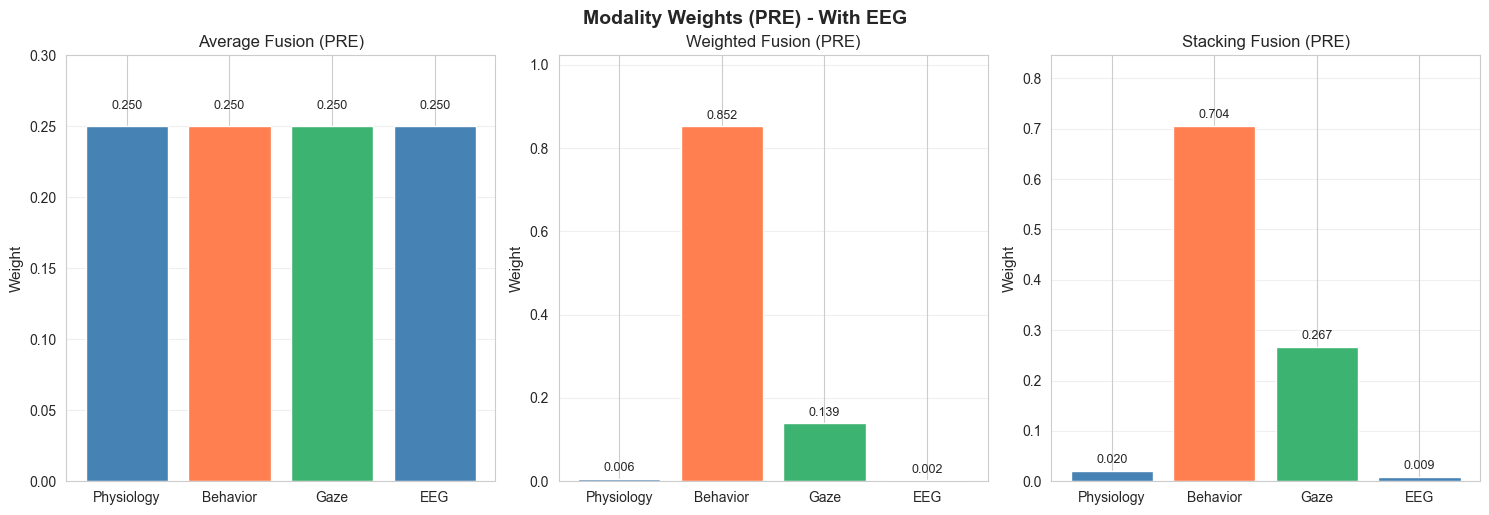

In [11]:
weights_df = pd.DataFrame({
    'Modality': modality_names,
    'Average': results_avg['weights'],
    'Weighted': results_weighted['weights'],
    'Stacking': results_stacking['weights']
})

print("\n" + "="*50)
print("MODALITY WEIGHTS (Influence on Prediction)")
print("="*50)
print(weights_df.to_string(index=False))

# Use shared plotting function
fig = plot_modality_weights(weights_df, timeframe=TIMEFRAME)
plt.suptitle(f'Modality Weights ({TIMEFRAME}) - With EEG', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 10. EEG Feature Importance


EEG FEATURE IMPORTANCES
            Feature  Importance
  eeg_Beta_Parietal    0.097106
   eeg_Beta_Frontal    0.089432
 eeg_Beta_Occipital    0.086482
  eeg_Theta_Frontal    0.079758
   eeg_Beta_Central    0.074078
  eeg_Alpha_Central    0.064696
  eeg_Alpha_Frontal    0.063456
  eeg_Theta_Central    0.059893
  eeg_Delta_Frontal    0.059758
  eeg_Delta_Central    0.058579
 eeg_Theta_Parietal    0.051309
 eeg_Alpha_Parietal    0.048410
eeg_Alpha_Occipital    0.045212
eeg_Delta_Occipital    0.045117
 eeg_Delta_Parietal    0.044012
eeg_Theta_Occipital    0.032703


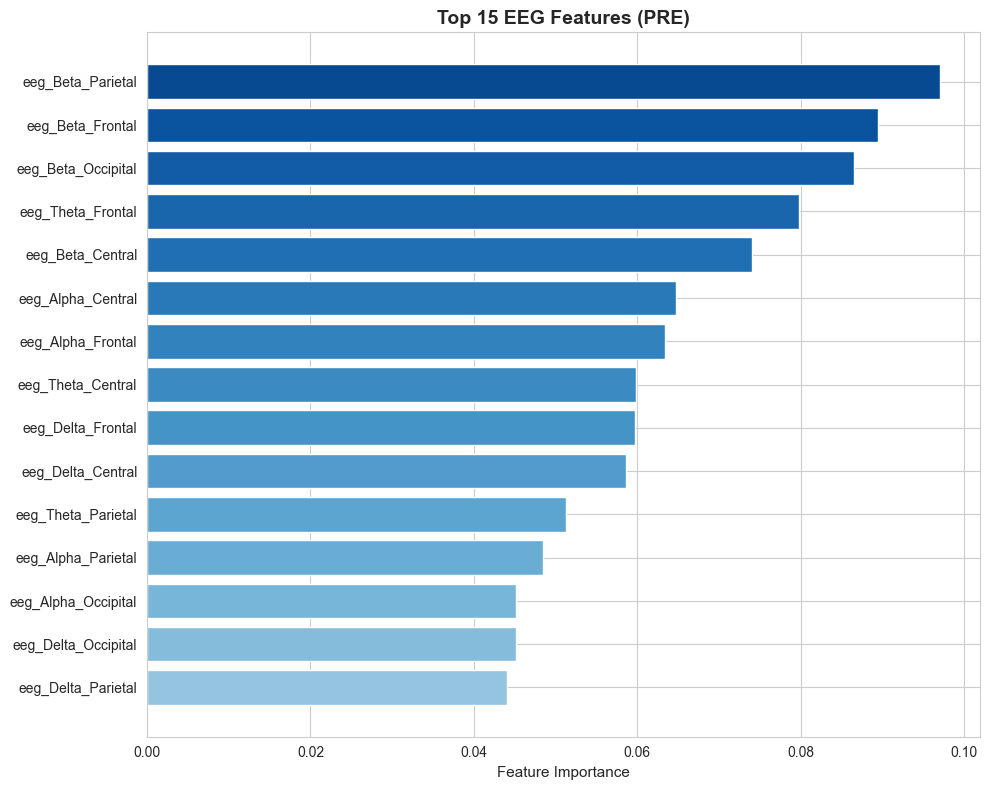

In [12]:
# Get EEG feature importances from the last trained model
if model_eeg is not None:
    eeg_importances = pd.DataFrame({
        'Feature': eeg_cols,
        'Importance': model_eeg.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n" + "="*50)
    print("EEG FEATURE IMPORTANCES")
    print("="*50)
    print(eeg_importances.to_string(index=False))
    
    # Visualize top features
    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = min(15, len(eeg_importances))
    
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))
    ax.barh(range(top_n), eeg_importances['Importance'].head(top_n).values[::-1], color=colors)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(eeg_importances['Feature'].head(top_n).values[::-1])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top {top_n} EEG Features ({TIMEFRAME})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 11. Save Results

In [13]:
# Save results using shared utility
import os
output_dir = f'../../data/results/main/eeg_integration/fusion_models_eeg_{TIMEFRAME}'
os.makedirs(output_dir, exist_ok=True)

# 1. Save method comparison results
save_results(comparison_df, 
             f'{output_dir}/late_fusion_with_eeg_{TIMEFRAME}_method_comparison.csv')

# 2. Save modality weights
save_results(weights_df,
             f'{output_dir}/late_fusion_with_eeg_{TIMEFRAME}_modality_weights.csv')

# 3. Save weighted fusion summary
weighted_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Accuracy_SEM', 'F1_Score', 'F1_SEM', 'N_Subjects', 'N_Trials'],
    'Value': [
        results_weighted['accuracy_mean'],
        results_weighted['accuracy_sem'],
        results_weighted['f1_mean'],
        results_weighted['f1_sem'],
        results_weighted['n_subjects'],
        results_weighted['n_trials']
    ]
})
save_results(weighted_summary,
             f'{output_dir}/late_fusion_with_eeg_{TIMEFRAME}_weighted_fusion_summary.csv')

# 4. Save subject-level accuracies
subject_df = pd.DataFrame({
    'subject_id': list(results_weighted['subject_accs'].keys()),
    'accuracy': list(results_weighted['subject_accs'].values())
})
save_results(subject_df,
             f'{output_dir}/late_fusion_with_eeg_{TIMEFRAME}_subject_accuracies.csv')
print(f"  - {len(subject_df)} subjects, Mean accuracy: {subject_df['accuracy'].mean():.4f}")

# 5. Save EEG feature importances
if model_eeg is not None:
    save_results(eeg_importances,
                 f'{output_dir}/late_fusion_with_eeg_{TIMEFRAME}_eeg_feature_importances.csv')

print(f"\nAll results saved to: {output_dir}/")

✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_method_comparison.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_modality_weights.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_weighted_fusion_summary.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_subject_accuracies.csv
  - 80 subjects, Mean accuracy: 0.7493
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_eeg_feature_importances.csv

All results saved to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/
